In [26]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [29]:
# Adjusted function based on the clarified structure and reading of the "F" key
def create_schedule_from_f_data(data):
    schedule = []
    
    for antigen, time_periods in data.items():
        for start_period, end_data in sorted(time_periods.items(), key=lambda x: int(x[0])):
            consecutive_starts = []
            consecutive_ends = []
            
            # Find consecutive periods with a value of 1
            for end_period, value in sorted(end_data.items(), key=lambda x: int(x[0])):
                if value == 1.0:
                    consecutive_starts.append(int(start_period))
                    consecutive_ends.append(int(end_period))
                    
            # Append all consecutive start-end ranges to the schedule
            if consecutive_starts and consecutive_ends:
                schedule.append((antigen, min(consecutive_starts), max(consecutive_ends)))
                
    return schedule

# Get the corrected schedule based on the new understanding
final_schedule = create_schedule_from_f_data(data['F'])

# Convert to DataFrame for easier viewing
final_schedule_df = pd.DataFrame(final_schedule, columns=["Antigen", "Starting", "Ending"])

final_schedule_df


,Antigen,Starting,Ending
0,PCV,1,3
1,PCV,4,7
2,PCV,7,10
3,Measles,1,3
4,Measles,3,7
5,Measles,7,10
6,Mumps,1,3
7,Mumps,4,7
8,Mumps,7,10
9,HPV,1,5


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


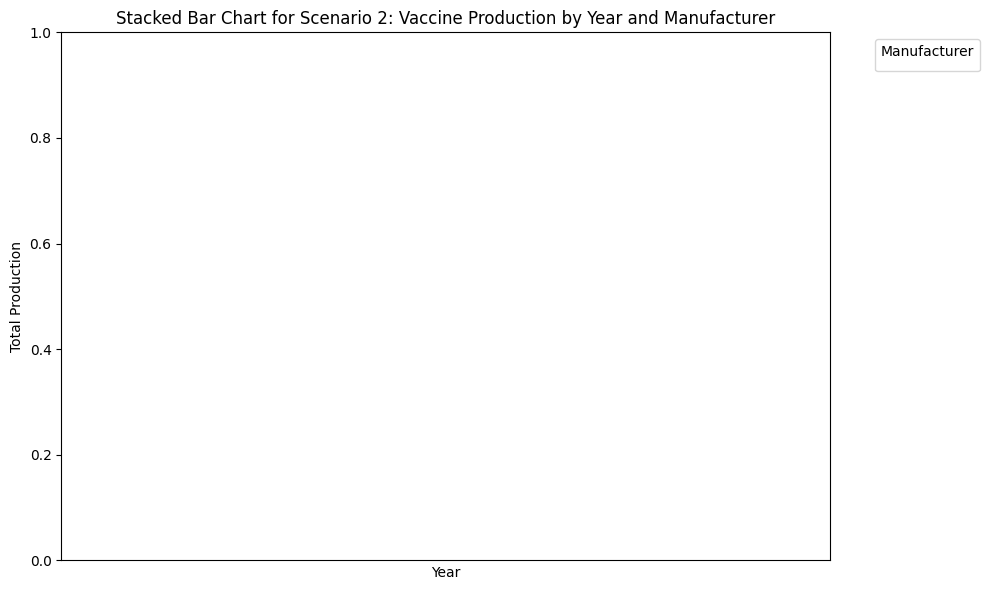

In [24]:
import json
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

# Load the JSON file
with open('DE_results_T_10_delta_5_scen_4_trial_1_inv_1_cap._1_cap.inc._2_base.json') as f:
    data = json.load(f)

# Initialize dictionaries for each scenario
scenarios = {1: defaultdict(dict), 2: defaultdict(dict), 3: defaultdict(dict), 4: defaultdict(dict)}

# Iterate through the JSON data
for vaccine, manufacturers in data['X'].items():
    for manufacturer, years in manufacturers.items():
        for year, scenarios_data in years.items():
            for scenario, value in scenarios_data.items():
                if scenario in scenarios:
                    if year not in scenarios[scenario][manufacturer]:
                        scenarios[scenario][manufacturer][year] = 0
                    scenarios[scenario][manufacturer][year] += value

# Data for scenario 2
scenario_2_data = scenarios[2]

# Collecting the years and manufacturers
years = sorted(set(year for manufacturer_data in scenario_2_data.values() for year in manufacturer_data))
manufacturers = sorted(scenario_2_data.keys())

# Initialize the bar heights for each year and manufacturer
bar_heights = {manufacturer: [scenario_2_data[manufacturer].get(year, 0) for year in years] for manufacturer in manufacturers}

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Colors from the 'tab20' colormap
colors = plt.get_cmap('tab20').colors

# Bottom trackers for stacking
bottom = np.zeros(len(years))

# Plot each manufacturer's data
for idx, manufacturer in enumerate(manufacturers):
    heights = bar_heights[manufacturer]
    ax.bar(years, heights, bottom=bottom, color=colors[idx % len(colors)], edgecolor='black', label=manufacturer)
    bottom += heights

# Add labels, title, and legend
ax.set_xlabel('Year')
ax.set_ylabel('Total Production')
ax.set_title('Stacked Bar Chart for Scenario 2: Vaccine Production by Year and Manufacturer')
ax.legend(title='Manufacturer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(years)  # Set x-ticks to years

# Adjust layout to fit legend
plt.tight_layout()

# Display the plot
plt.show()
